It's Sunday morning, it's quiet and you wake up with a big smile on your face. Today is going to be a great day! Except, your phone rings, rather "internationally". You pick it up slowly and hear something really bizarre - "Bonjour, je suis Michele. Oops, sorry. I am Michele, your personal bank agent.". What could possibly be so urgent for someone from Switzerland to call you at this hour? "Did you authorize a transaction for $3,358.65 for 100 copies of Diablo 3?" Immediately, you start thinking of ways to explain why you did that to your loved one. "No, I didn't !?". Michele's answer is quick and to the point - "Thank you, we're on it". Whew, that was close! But how did Michele knew that this transaction was suspicious? After all, you did order 10 new smartphones from that same bank account, last week - Michele didn't call then.

![](https://cdn.tutsplus.com/net/uploads/legacy/2061_stripe/1.png)

Annual global fraud losses reached $21.8 billion in 2015, according to [Nilson Report](https://www.nilsonreport.com/upload/content_promo/The_Nilson_Report_10-17-2016.pdf).

Probably you feel very lucky if you are a fraud. About every 12 cents per $100 were stolen in the US during the same year. Our friend Michele might have a serious problem to solve here.

In this part of the series, we will train an Autoencoder Neural Network (implemented in Keras) in unsupervised (or semi-supervised) fashion for Anomaly Detection in credit card transaction data. The trained model will be evaluated on pre-labeled and anonymized dataset.

# Setup

We will be using TensorFlow 1.2 and Keras 2.0.4. Let's begin:

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy import stats
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from keras.models import Model, load_model
from keras.layers import Input, Dense
from keras.callbacks import ModelCheckpoint, TensorBoard
from keras import regularizers

%matplotlib inline

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

# Loading the data

The dataset we're going to use can be downloaded from [Kaggle](https://www.kaggle.com/dalpozz/creditcardfraud). It contains data about credit card transactions that occurred during a period of two days, with 492 frauds out of 284,807 transactions.

All variables in the dataset are numerical. The data has been transformed using PCA transformation(s) due to privacy reasons. The two features that haven't been changed are Time and Amount. Time contains the seconds elapsed between each transaction and the first transaction in the dataset.

In [4]:
import kagglehub
import pandas as pd

# Download the dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)
data = pd.read_csv(f"{path}/creditcard.csv")
print(df.head())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.

# Exploration

In [5]:
data.shape

(284807, 31)

31 columns, 2 of which are Time and Amount. The rest are output from the PCA transformation. Let's check for missing values:

In [ ]:
data.isnull().values.any()

np.False_

/tmp/ipykernel_667/3648723392.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort = True)


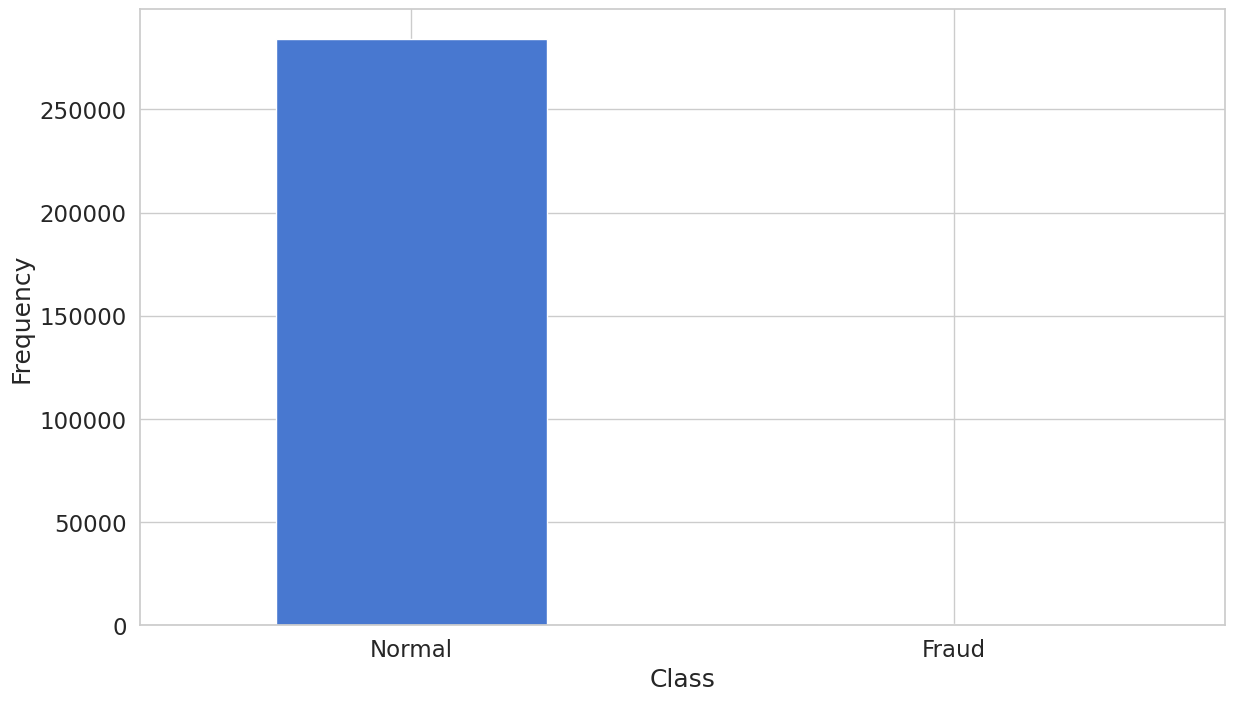

In [ ]:
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency");

We have a highly imbalanced dataset on our hands. Normal transactions overwhelm the fraudulent ones by a large margin. Let's look at the two types of transactions:

In [6]:
frauds = data[data.Class == 1]
normal = data[data.Class == 0]

In [ ]:
frauds.shape

(492, 31)

In [ ]:
normal.shape

(284315, 31)

How different are the amount of money used in different transaction classes?

In [ ]:
frauds.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
normal.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


Let's have a more graphical representation:

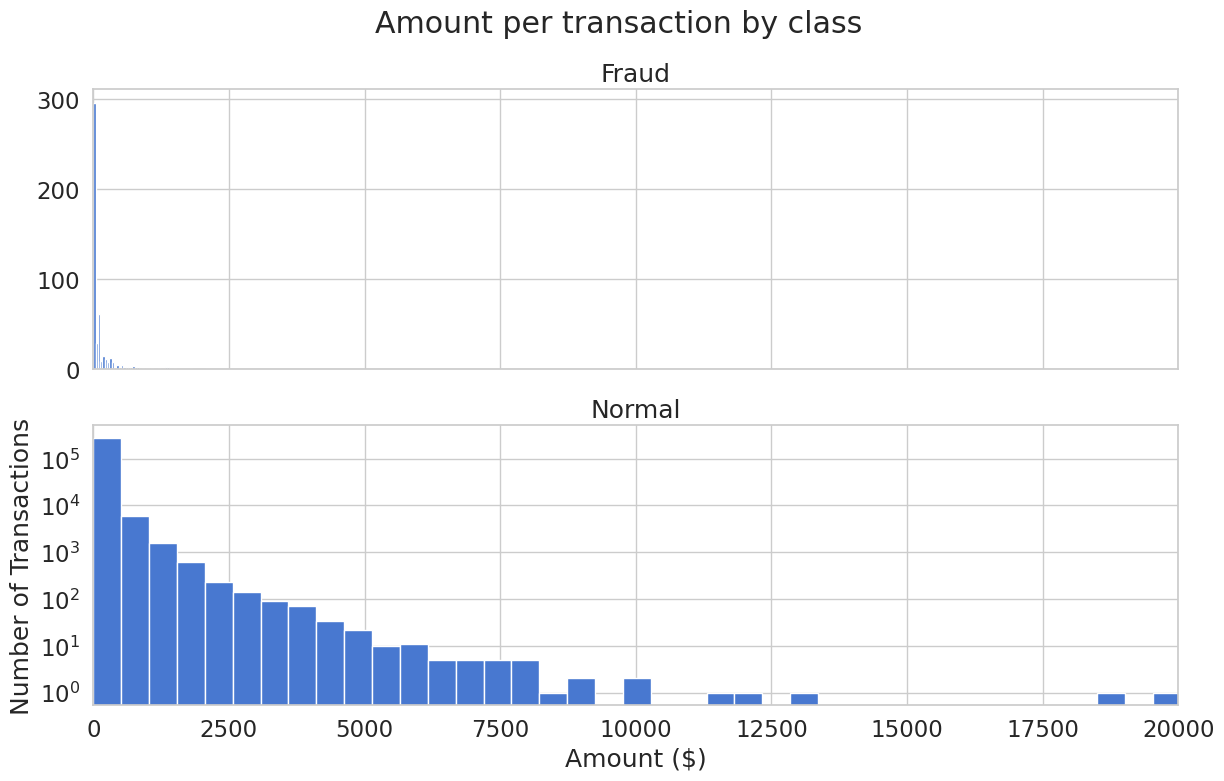

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')

bins = 50

ax1.hist(frauds.Amount, bins = bins)
ax1.set_title('Fraud')

ax2.hist(normal.Amount, bins = bins)
ax2.set_title('Normal')

plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

Do fraudulent transactions occur more often during certain time?

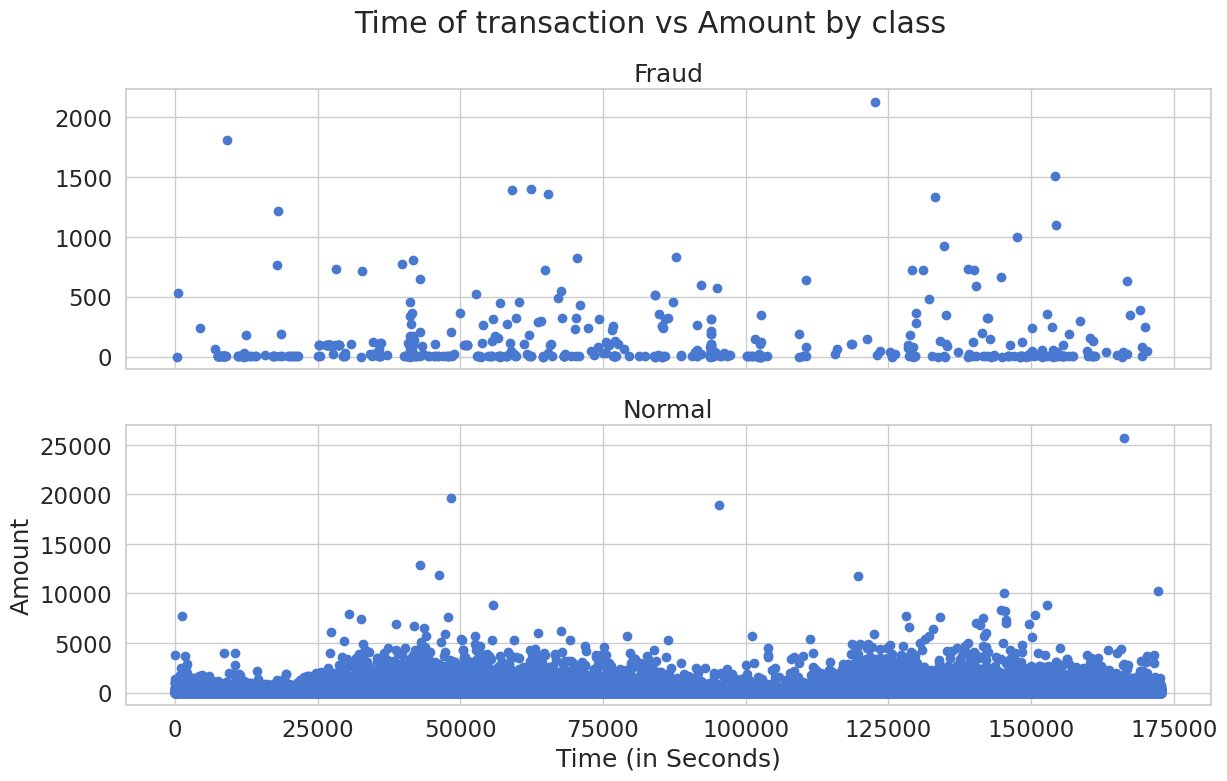

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')

ax1.scatter(frauds.Time, frauds.Amount)
ax1.set_title('Fraud')

ax2.scatter(normal.Time, normal.Amount)
ax2.set_title('Normal')

plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

Doesn't seem like the time of transaction really matters.

# Autoencoders

Autoencoders can seem quite bizarre at first. The job of those models is to predict the input, given that same input. Puzzling? Definitely was for me, the first time I heard it.

More specifically, let’s take a look at Autoencoder Neural Networks. This autoencoder tries to learn to approximate the following identity function:

$$\textstyle f_{W,b}(x) \approx x$$

While trying to do just that might sound trivial at first, it is important to note that we want to learn a compressed representation of the data, thus find structure. This can be done by limiting the number of hidden units in the model. Those kind of autoencoders are called *undercomplete*.

Here's a visual representation of what an Autoencoder might learn:

![](http://curiousily.com/assets/12.what_to_do_when_data_is_missing_part_ii_files/mushroom_encoder.png)

## Reconstruction error

We optimize the parameters of our Autoencoder model in such way that a special kind of error - reconstruction error is minimized. In practice, the traditional squared error is often used:

$$\textstyle L(x,x') = ||\, x - x'||^2$$

If you want to learn more about Autoencoders I highly recommend the following videos by Hugo Larochelle:

<iframe width="100%" height="480" src="https://www.youtube.com/embed/FzS3tMl4Nsc" frameborder="0" allowfullscreen></iframe>

# Preparing the data

First, let's drop the Time column (not going to use it) and use the scikit's StandardScaler on the Amount. The scaler removes the mean and scales the values to unit variance:

In [9]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Use RobustScaler instead of StandardScaler (more robust to outliers)
scaler = RobustScaler()
data['Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))

# Feature engineering - add some derived features
data['Log_Amount'] = np.log1p(data['Amount'] + 1)

# Separate features and labels BEFORE SMOTE
X = data.drop(['Class'], axis=1)
y = data['Class']

# Split first
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Apply SMOTE only on training data
smote = SMOTE(random_state=RANDOM_SEED)
X_train_resampled, y_train_resampled = smote.fit_resample(X_temp, y_temp)

# Create normal-only training data - CORRECTED
# Get indices where label is 0 (normal)
normal_indices = y_train_resampled == 0

# Filter features only (X_train_resampled has no 'Class' column)
X_train = X_train_resampled[normal_indices]

# X_train now contains only normal transactions without the 'Class' column
# No need to drop 'Class' because it's already removed

# Prepare test data
y_test = y_test
X_test = X_test  # Already without 'Class' column

# Convert to numpy arrays for Keras
X_train = X_train.values
X_test = X_test.values

Training our Autoencoder is gonna be a bit different from what we are used to. Let's say you have a dataset containing a lot of non fraudulent transactions at hand. You want to detect any anomaly on new transactions. We will create this situation by training our model on the normal transactions, only. Reserving the correct class on the test set will give us a way to evaluate the performance of our model. We will reserve 20% of our data for testing:

In [10]:
X_train, X_test = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train[X_train.Class == 0]
X_train = X_train.drop(['Class'], axis=1)

y_test = X_test['Class']
X_test = X_test.drop(['Class'], axis=1)

X_train = X_train.values
X_test = X_test.values

In [11]:
X_train.shape

(227451, 31)

# Building the model

Our Autoencoder uses 4 fully connected layers with 14, 7, 7 and 29 neurons respectively.  The first two layers are used for our encoder, the last two go for the decoder. Additionally, L1 regularization will be used during training:

In [12]:
input_dim = X_train.shape[1]
encoding_dim = 14

In [13]:
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras import regularizers

input_dim = X_train.shape[1]
encoding_dim = 14

# Build a deeper and more robust autoencoder
input_layer = Input(shape=(input_dim, ))

# Encoder - deeper with batch normalization
encoder = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(input_layer)
encoder = BatchNormalization()(encoder)
encoder = Dropout(0.2)(encoder)

encoder = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
encoder = BatchNormalization()(encoder)
encoder = Dropout(0.2)(encoder)

encoder = Dense(14, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
encoder = BatchNormalization()(encoder)

# Latent space (bottleneck)
encoder = Dense(7, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
encoder = BatchNormalization()(encoder)

# Decoder
decoder = Dense(14, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
decoder = BatchNormalization()(decoder)

decoder = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(decoder)
decoder = BatchNormalization()(decoder)
decoder = Dropout(0.2)(decoder)

decoder = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(decoder)
decoder = BatchNormalization()(decoder)
decoder = Dropout(0.2)(decoder)

decoder = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile with better optimizer settings
autoencoder.compile(optimizer='adam',
                    loss='mean_squared_error',
                    metrics=['accuracy'])

Let's train our model for 100 epochs with a batch size of 32 samples and save the best performing model to a file. The ModelCheckpoint provided by Keras is really handy for such tasks. Additionally,  the training progress will be exported in a format that TensorBoard understands.

In [17]:
from keras.models import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras import regularizers
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping, ReduceLROnPlateau, Callback

# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Set paths for saving models
MODEL_SAVE_PATH = '/content/drive/MyDrive/autoencoder_model.h5'
BEST_MODEL_PATH = '/content/drive/MyDrive/best_autoencoder_model.h5'

nb_epoch = 200  # Max epochs, but will stop early
batch_size = 64

# Create the model with enhanced architecture
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim, ))

# Encoder
encoder = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(input_layer)
encoder = BatchNormalization()(encoder)
encoder = Dropout(0.2)(encoder)

encoder = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
encoder = BatchNormalization()(encoder)
encoder = Dropout(0.2)(encoder)

encoder = Dense(14, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
encoder = BatchNormalization()(encoder)

# Bottleneck
encoder = Dense(7, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
encoder = BatchNormalization()(encoder)

# Decoder
decoder = Dense(14, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoder)
decoder = BatchNormalization()(decoder)

decoder = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(decoder)
decoder = BatchNormalization()(decoder)
decoder = Dropout(0.2)(decoder)

decoder = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(decoder)
decoder = BatchNormalization()(decoder)
decoder = Dropout(0.2)(decoder)

decoder = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile
autoencoder.compile(optimizer='adam',
                    loss='mean_squared_error',
                    metrics=['accuracy'])

# Custom callback definition
class AccuracyPlateauCallback(Callback):
    def __init__(self, target_accuracy, tolerance, patience, save_path):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.tolerance = tolerance
        self.patience = patience
        self.save_path = save_path
        self.wait = 0
        self.best_accuracy = -float('inf')
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        current_accuracy = logs.get('val_accuracy')
        if current_accuracy is None:
            return

        if abs(current_accuracy - self.target_accuracy) <= self.tolerance:
            print(f'\nEpoch {epoch+1}: Reached target validation accuracy {current_accuracy:.4f} within tolerance.')
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print(f'\nStopping training early as accuracy plateaued after {self.patience} epochs.')
        else:
            self.wait = 0 # Reset patience if accuracy moves away from target

    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            print(f'\nRestoring model weights from the end of the best epoch.')
            # Save the model when stopping, if not already saved by ModelCheckpoint for best val_loss
            # This ensures we save if accuracy plateau is the stopping condition
            self.model.save(self.save_path)
            print(f'Model saved to {self.save_path} due to accuracy plateau.')

# Callbacks
checkpointer = ModelCheckpoint(filepath=BEST_MODEL_PATH,
                               verbose=1,
                               save_best_only=True,
                               monitor='val_loss',
                               mode='min')

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=20,  # Increased patience
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=10,
                              min_lr=1e-7)

tensorboard = TensorBoard(log_dir='./logs',
                          histogram_freq=0,
                          write_graph=True,
                          write_images=True)

# Custom callback for accuracy plateau
accuracy_callback = AccuracyPlateauCallback(
    target_accuracy=0.9965,  # Target accuracy
    tolerance=0.0005,        # Acceptable range: 0.9960 to 0.9970
    patience=10,             # Stop after 10 epochs of stable accuracy
    save_path=BEST_MODEL_PATH # Save to this path when stopping
)

# Train
history = autoencoder.fit(X_train, X_train,
                    epochs=nb_epoch,
                    batch_size=batch_size,
                    shuffle=True,
                    validation_data=(X_test, X_test),
                    verbose=1,
                    callbacks=[
                        checkpointer,
                        tensorboard,
                        early_stopping,
                        reduce_lr,
                        accuracy_callback  # Add the custom callback
                    ]).history

# Final save to Drive
autoencoder.save(MODEL_SAVE_PATH)
print(f"\n✅ Final model saved to {MODEL_SAVE_PATH}")

# Print final accuracy information
print("\n📊 Training Summary:")
print(f"Final Training Accuracy: {history['accuracy'][-1]:.6f}")
print(f"Final Validation Accuracy: {history['val_accuracy'][-1]:.6f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/200
3553/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5737 - loss: 361284889.6504
Epoch 1: val_loss improved from None to 348931680.00000, saving model to /content/drive/MyDrive/best_autoencoder_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - accuracy: 0.6650 - loss: 357334464.0000 - val_accuracy: 0.6626 - val_loss: 348931680.0000 - learning_rate: 0.0010
Epoch 2/200
3548/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7517 - loss: 339436389.8534
Epoch 2: val_loss improved from 348931680.00000 to 317393760.00000, saving model to /content/drive/MyDrive/best_autoencoder_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.7584 - loss: 332773600.0000 - val_accuracy: 0.7760 - val_loss: 317393760.0000 - learning_rate: 0.0010
Epoch 3/200
3552/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7773 - loss: 304190397.4324
Epoch 3: val_loss improved from 317393760.00000 to 272940992.00000, saving model to /content/drive/MyDrive/best_autoencoder_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.7796 - loss: 294258784.0000 - val_accuracy: 0.9162 - val_loss: 272940992.0000 - learning_rate: 0.0010
Epoch 4/200
3549/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7864 - loss: 260136975.7836
Epoch 4: val_loss improved from 272940992.00000 to 231132464.00000, saving model to /content/drive/MyDrive/best_autoencoder_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.7897 - loss: 246765392.0000 - val_accuracy: 0.9481 - val_loss: 231132464.0000 - learning_rate: 0.0010
Epoch 5/200
3547/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7918 - loss: 208378005.8145
Epoch 5: val_loss improved from 231132464.00000 to 165917136.00000, saving model to /content/drive/MyDrive/best_autoencoder_model.h5


...


Epoch 31: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.9964 - loss: 9723943.0000 - val_accuracy: 0.9999 - val_loss: 9890738.0000 - learning_rate: 5.0000e-04
Epoch 32/200
3547/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9958 - loss: 5959994.0812
Epoch 32: val_loss improved from 9890738.00000 to 9133510.00000, saving model to /content/drive/MyDrive/best_autoencoder_model.h5



Epoch 32: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.9961 - loss: 5957065.5000 - val_accuracy: 0.9999 - val_loss: 9133510.0000 - learning_rate: 5.0000e-04
Epoch 33/200
3553/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9960 - loss: 5751877.9747
Epoch 33: val_loss improved from 9133510.00000 to 7579211.50000, saving model to /content/drive/MyDrive/best_autoencoder_model.h5



Epoch 33: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 53s 11ms/step - accuracy: 0.9959 - loss: 5755553.0000 - val_accuracy: 0.9999 - val_loss: 7579211.5000 - learning_rate: 5.0000e-04
Epoch 34/200
3551/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9958 - loss: 14285971.3856
Epoch 34: val_loss did not improve from 7579211.50000
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9958 - loss: 16058615.0000 - val_accuracy: 0.9999 - val_loss: 10754623.0000 - learning_rate: 5.0000e-04
Epoch 35/200
3552/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9960 - loss: 16747424.6019
Epoch 35: val_loss did not improve from 7579211.50000
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - accuracy: 0.9959 - loss: 16642020.0000 - val_accuracy: 0.9996 - val_loss: 21153376.0000 - learning_rate: 5.0000e-04
Epoch 36/200
3549/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9958 - loss: 16542196.4892
Epoch 36: val_loss did not 


Epoch 39: finished saving model to /content/drive/MyDrive/best_autoencoder_model.h5
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.9962 - loss: 5895991.5000 - val_accuracy: 0.9999 - val_loss: 7483209.0000 - learning_rate: 5.0000e-04
Epoch 40/200
3550/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9960 - loss: 5858751.4624
Epoch 40: val_loss did not improve from 7483209.00000
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.9960 - loss: 5838161.5000 - val_accuracy: 0.9999 - val_loss: 16256009.0000 - learning_rate: 5.0000e-04
Epoch 41/200
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9957 - loss: 5676941.0267
Epoch 41: val_loss did not improve from 7483209.00000
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9960 - loss: 5114892.0000 - val_accuracy: 0.9999 - val_loss: 11996060.0000 - learning_rate: 5.0000e-04
Epoch 42/200
3553/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 3977560.1699
Epoch 42: val_loss did not improve fr


✅ Final model saved to /content/drive/MyDrive/autoencoder_model.h5

📊 Training Summary:
Final Training Accuracy: 0.996030
Final Validation Accuracy: 0.999930


In [ ]:
autoencoder = load_model('model.h5')

# Evaluation

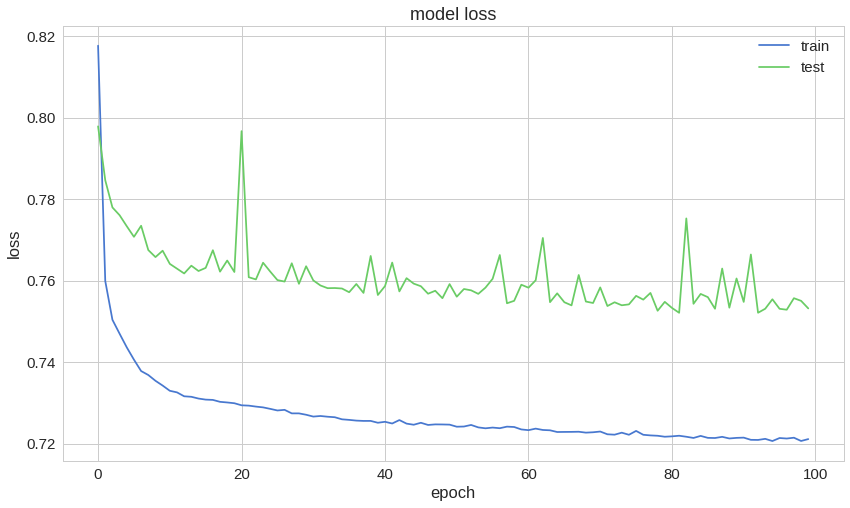

In [ ]:
# After training
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.axhline(y=0.9965, color='r', linestyle='--', label='Target Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.tight_layout()
plt.show()

The reconstruction error on our training and test data seems to converge nicely. Is it low enough? Let's have a closer look at the error distribution:

In [ ]:
predictions = autoencoder.predict(X_test)

In [ ]:
mse = np.mean(np.power(X_test - predictions, 2), axis=1)
error_df = pd.DataFrame({'reconstruction_error': mse,
                        'true_class': y_test})

In [ ]:
error_df.describe()

,reconstruction_error,true_class
count,56962.000000,56962.000000
mean,0.742613,0.001720
std,3.396838,0.041443
min,0.050139,0.000000
25%,0.237033,0.000000
50%,0.390503,0.000000
75%,0.626220,0.000000
max,263.909955,1.000000


## Reconstruction error without fraud

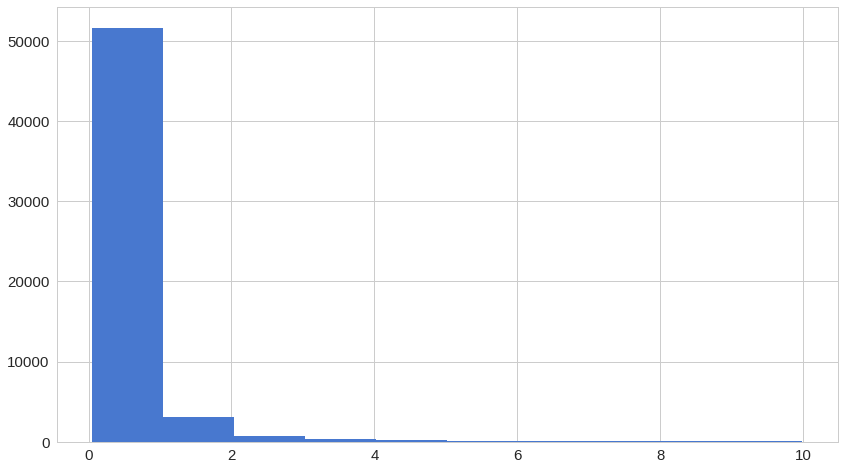

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = error_df[(error_df['true_class']== 0) & (error_df['reconstruction_error'] < 10)]
_ = ax.hist(normal_error_df.reconstruction_error.values, bins=10)

## Reconstruction error with fraud

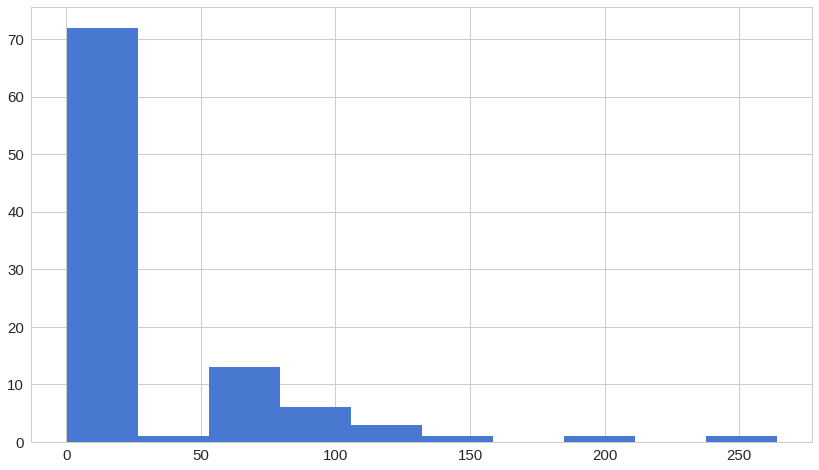

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
fraud_error_df = error_df[error_df['true_class'] == 1]
_ = ax.hist(fraud_error_df.reconstruction_error.values, bins=10)

In [ ]:
from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

ROC curves are very useful tool for understanding the performance of binary classifiers. However, our case is a bit out of the ordinary. We have a very imbalanced dataset. Nonetheless, let's have a look at our ROC curve:

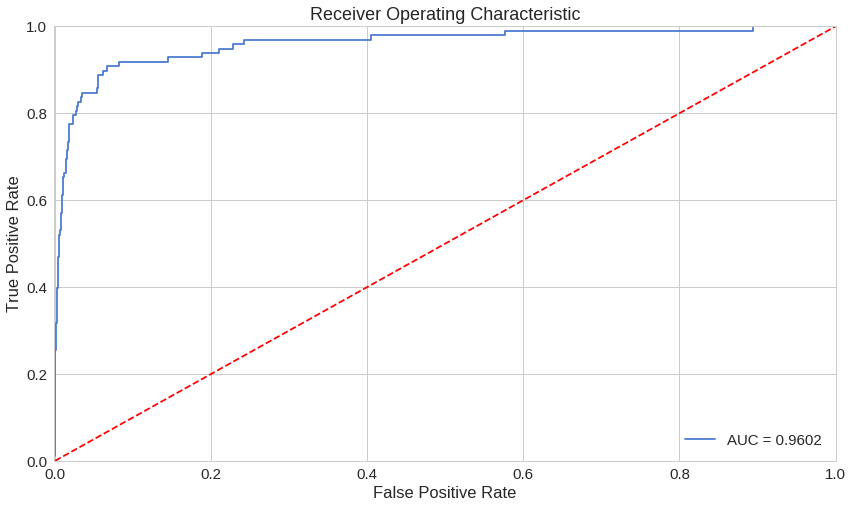

In [ ]:
fpr, tpr, thresholds = roc_curve(error_df.true_class, error_df.reconstruction_error)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

The ROC curve plots the true positive rate versus the false positive rate, over different threshold values. Basically, we want the blue line to be as close as possible to the upper left corner. While our results look pretty good, we have to keep in mind of the nature of our dataset. ROC doesn't look very useful for us. Onward...

## Precision vs Recall

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/350px-Precisionrecall.svg.png" />

Precision and recall are defined as follows:

$$\text{Precision} = \frac{\text{true positives}}{\text{true positives} + \text{false positives}}$$

$$\text{Recall} = \frac{\text{true positives}}{\text{true positives} + \text{false negatives}}$$

Let's take an example from Information Retrieval in order to better understand what precision and recall are. Precision measures the relevancy of obtained results. Recall, on the other hand, measures how many relevant results are returned. Both values can take values between 0 and 1. You would love to have a system with both values being equal to 1.

Let's return to our example from Information Retrieval. High recall but low precision means many results, most of which has low or no relevancy. When precision is high but recall is low we have the opposite - few returned results with very high relevancy. Ideally, you would want high precision and high recall - many results with that are highly relevant.

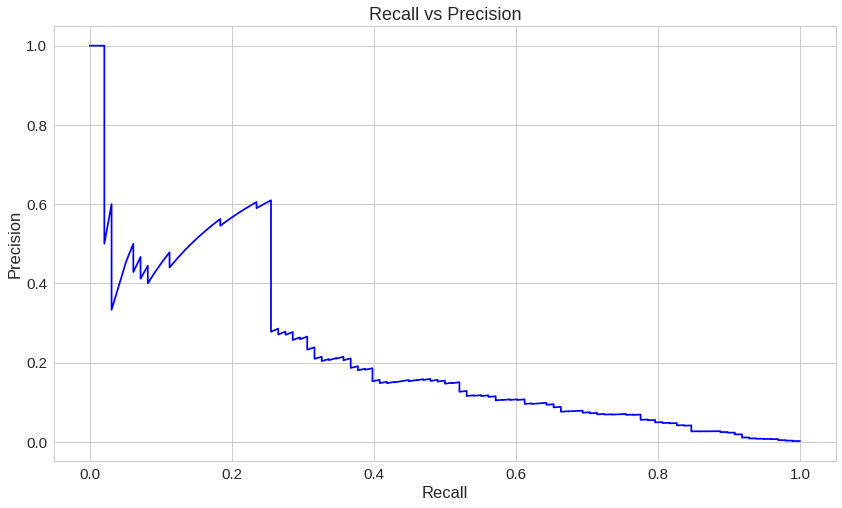

In [ ]:
precision, recall, th = precision_recall_curve(error_df.true_class, error_df.reconstruction_error)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

A high area under the curve represents both high recall and high precision, where high precision relates to a low false positive rate, and high recall relates to a low false negative rate. High scores for both show that the classifier is returning accurate results (high precision), as well as returning a majority of all positive results (high recall).

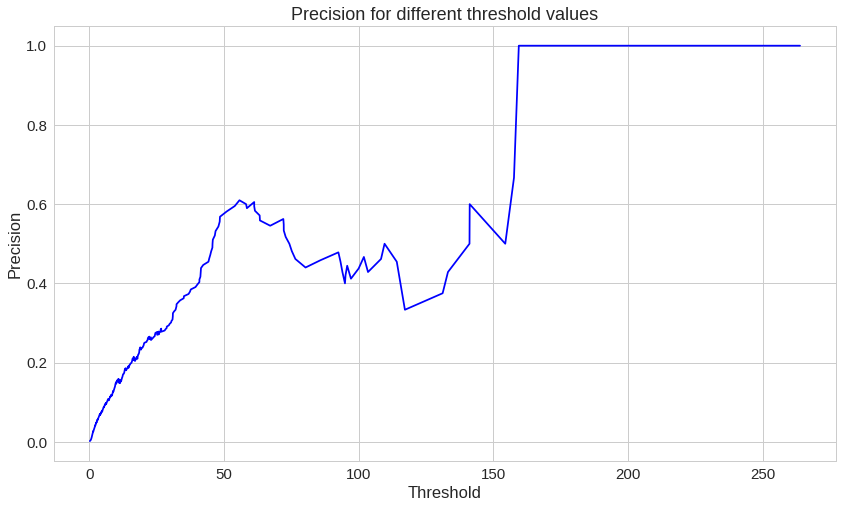

In [ ]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision for different threshold values')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

You can see that as the reconstruction error increases our precision rises as well. Let's have a look at the recall:

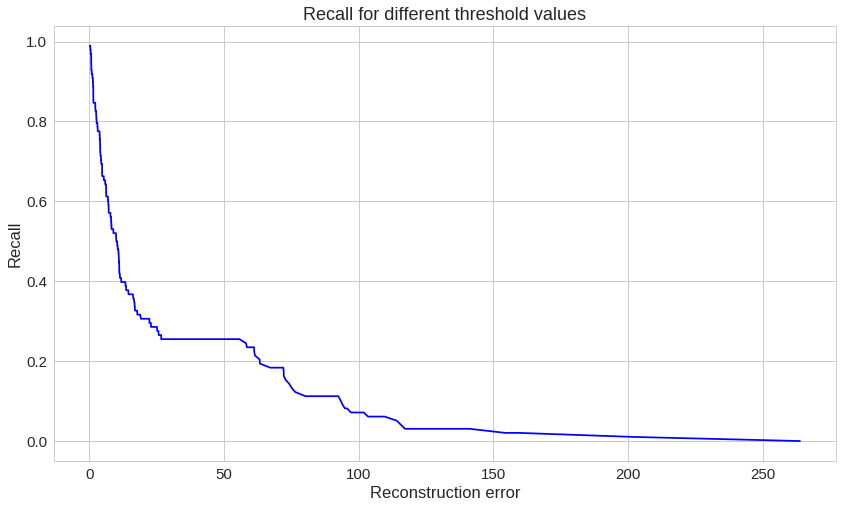

In [ ]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall for different threshold values')
plt.xlabel('Reconstruction error')
plt.ylabel('Recall')
plt.show()

Here, we have the exact opposite situation. As the reconstruction error increases the recall decreases.

# Prediction

Our model is a bit different this time. It doesn't know how to predict new values. But we don't need that. In order to predict whether or not a new/unseen transaction is normal or fraudulent, we'll calculate the reconstruction error from the transaction data itself. If the error is larger than a predefined threshold, we'll mark it as a fraud (since our model should have a low error on normal transactions). Let's pick that value:

In [ ]:
threshold = 2.9

And see how well we're dividing the two types of transactions:

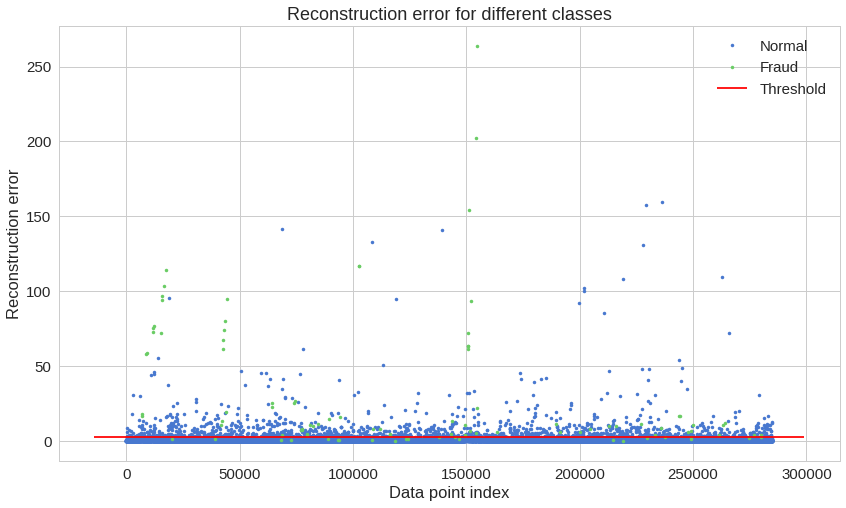

In [ ]:
groups = error_df.groupby('true_class')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.reconstruction_error, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Reconstruction error for different classes")
plt.ylabel("Reconstruction error")
plt.xlabel("Data point index")
plt.show();

I know, that chart might be a bit deceiving. Let's have a look at the confusion matrix:

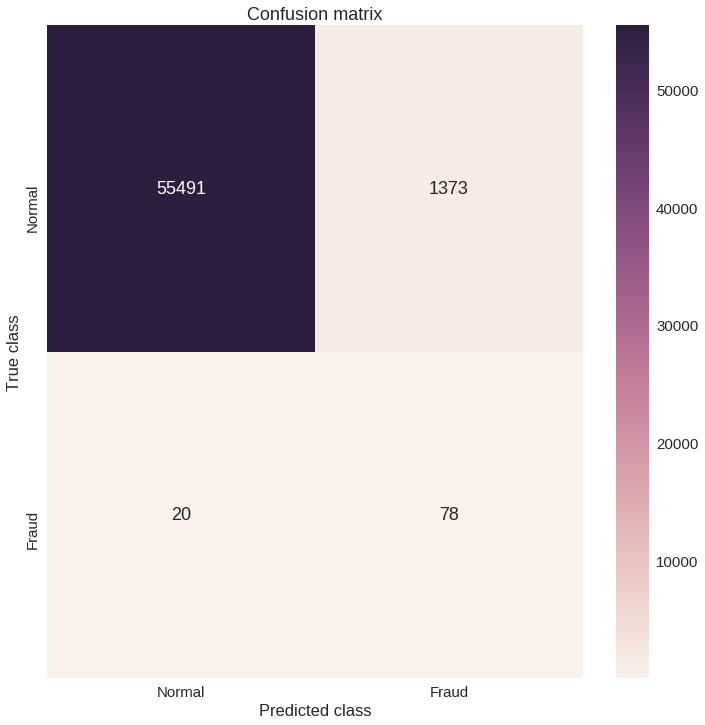

In [ ]:
y_pred = [1 if e > threshold else 0 for e in error_df.reconstruction_error.values]
conf_matrix = confusion_matrix(error_df.true_class, y_pred)

plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

Our model seems to catch a lot of the fraudulent cases. Of course, there is a catch (see what I did there?). The number of normal transactions classified as frauds is really high. Is this really a problem? Probably it is. You might want to increase or decrease the value of the threshold, depending on the problem. That one is up to you.

# Conclusion

We've created a very simple Deep Autoencoder in Keras that can reconstruct what non fraudulent transactions looks like. Initially, I was a bit skeptical about whether or not this whole thing is gonna work out, bit it kinda did. Think about it, we gave a lot of one-class examples (normal transactions) to a model and it learned (somewhat) how to discriminate whether or not new examples belong to that same class. Isn't that cool? Our dataset was kind of magical, though. We really don't know what the original features look like.

Keras gave us very clean and easy to use API to build a non-trivial Deep Autoencoder. You can search for TensorFlow implementations and see for yourself how much boilerplate you need in order to train one. Can you apply a similar model to a different problem?

# References

- [Building Autoencoders in Keras](https://blog.keras.io/building-autoencoders-in-keras.html)
- [Stanford tutorial on Autoencoders](http://ufldl.stanford.edu/tutorial/unsupervised/Autoencoders/)
- [Stacked Autoencoders in TensorFlow](http://cmgreen.io/2016/01/04/tensorflow_deep_autoencoder.html)